# Название проекта

## Описание проекта

## Цель исследования

## Ход исследования

В процессе исследования будут проведены следующие действия
- подготовка данных: загрузка и изучение общей информации из предоставленных датасетов
- предобработка данных: обработка пропущенных значений, обработка дублей, корректировка данных
- проведение анализа представленных данных: выявление закономерностей и аномалий, распределения данных по параметрам
- объединение данных в единый датасет и его расширение дополнительной информацией на основе представленных данных
- выявление лучших моделей для задач регрессии и бинарной классификации целевых признаков с использованием пайплайнов
- резюмирование полученных результатов, формулировка общих выводов и рекомендаций

## Настройка окружения

### Импорты

In [198]:
# %pip install -Uq scikit-learn
# %pip install phik -q
# %pip install shap -q

# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import shap

# import warnings
# warnings.filterwarnings('ignore', category=pd.core.common.SettingWithCopyWarning)

from phik import phik_matrix
from plotly.subplots import make_subplots
from scipy import stats as st
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    make_scorer,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PolynomialFeatures,
)

from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    RandomizedSearchCV,
)

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


### Настройки отображения

In [199]:
# output settings
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option('display.max_colwidth', None)

### Объявление функций

In [200]:
def check_size(current_df: pd.DataFrame, original_df: pd.DataFrame):
    print("Количество записей в текущем датасете: {}".format(len(current_df)))
    print("Количество записей в оригинальном датасете: {}".format(len(original_df)))
    print("Процент от начального объема данных: {:.2%}".format(len(current_df) / len(original_df)))

In [201]:
import os

HOST = "https://code.s3.yandex.net"
HTTP_PREFIX = "http"


# load csv
def load_csv(dataset_path: str, **kwargs):
    # def load_csv(dataset_path, delimiter=",", decimal=".", index_col=None):
    # check server request --> relative path --> absolute path --> yandex server request
    path = (
        dataset_path
        if dataset_path.startswith(HTTP_PREFIX)
        else "." + dataset_path if os.path.exists("." + dataset_path)
        else dataset_path if os.path.exists(dataset_path) 
        else HOST + dataset_path
    )
    print("Dataset path:", path)
    try:
        return pd.read_csv(filepath_or_buffer=path, **kwargs)
        # return pd.read_csv(path, delimiter=delimiter, decimal=decimal, index_col=index_col)
    except Exception as ex:
        print("Could not load csv. Exception:", str(ex))

In [202]:
def df_init_analysis(df_name: str, df: pd.DataFrame):
    print("=" * 50)
    print(f"{df_name}\n")
    print("Общая информация\n")
    print(df.info())

    print("\nБазовая статистика по данным")
    display(df.describe(include='all'))

    print("\nИнформация по колонкам\n")
    df_init_analysis_column_names = [
        "column_name",
        "type",
        "na_count",
        "empty_count",
        "unique_count",
    ]

    df_init_analysis_data = []
    for column_name in df.columns.tolist():
        df_init_column_data = []
        df_init_column_data.append(column_name)
        df_init_column_data.append(df[column_name].dtype)
        df_init_column_data.append(df[column_name].isna().sum())
        df_init_column_data.append(sum(df[column_name] == ""))
        df_init_column_data.append(df[column_name].nunique())
        df_init_analysis_data.append(df_init_column_data)

    df_init = pd.DataFrame(columns=df_init_analysis_column_names, data=df_init_analysis_data)
    display(df_init)

    print(f"\nКоличество явных дубликатов: {df.duplicated().sum()}\n")

In [203]:
def rename_columns_to_lowercase(columns_list):
    """
    Преобразует названия столбцов датафрейма в lowercase и заменяет пробелы на "_".
    
    :param columns_list: Список текущих названий столбцов датафрейма
    :return: Отформатированный список новых названий столбцов
    """
    new_columns = []
    for col in columns_list:
        # Приводим название столбца к нижнему регистру и заменяем пробелы на _
        new_col_name = col.lower().replace(' ', '_')
        new_columns.append(new_col_name)
    return new_columns

## Загрузка данных

In [204]:
df_heart_train_original = load_csv(".private/heart_train.csv", index_col=0)
df_heart_train = df_heart_train_original.copy().set_index("id")
df_heart_train.head()

Dataset path: .private/heart_train.csv


,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,,
2664,0.36,0.73,0.07,1.00,1.00,1.00,1.00,1.00,0.54,1,1.00,0.00,8.00,0.23,0.11,0.46,0.98,3.00,0.33,0.00,0.23,0.05,0.04,Male,0.21,0.71
9287,0.20,0.33,0.05,1.00,1.00,0.00,0.00,1.00,0.07,2,1.00,0.00,9.00,0.29,0.16,0.12,0.52,3.00,0.83,0.00,0.15,0.02,0.00,Female,0.41,0.57
5379,0.61,0.86,0.06,1.00,0.00,1.00,1.00,1.00,0.94,2,1.00,1.00,6.00,0.55,0.60,0.37,0.01,2.00,1.00,0.00,0.23,0.05,0.04,Female,0.24,0.22
8222,0.73,0.01,0.05,0.00,0.00,1.00,0.00,1.00,0.70,0,0.00,1.00,3.00,0.33,0.08,0.05,0.13,0.00,0.33,1.00,0.23,0.05,0.04,Female,0.35,0.27
4047,0.78,0.76,0.02,0.00,0.00,1.00,0.00,1.00,0.41,1,0.00,0.00,8.00,0.52,0.34,0.83,0.07,5.00,1.00,1.00,0.23,0.05,0.04,Male,0.62,0.44


In [205]:
df_heart_test_original = load_csv(".private/heart_test.csv", index_col=0)
df_heart_test = df_heart_test_original.copy().set_index("id")
df_heart_test.head()

Dataset path: .private/heart_test.csv


,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,
7746,0.49,0.26,0.06,0.00,1.00,1.00,1.00,1.00,0.36,2,0.00,0.00,8.00,0.19,0.59,0.28,0.31,1.00,0.33,0.23,0.05,0.04,Male,0.28,0.37
4202,0.22,0.95,0.08,1.00,0.00,0.00,1.00,0.00,1.00,2,1.00,1.00,5.00,0.33,0.60,0.47,0.09,0.00,0.17,0.23,0.05,0.04,Female,0.70,0.44
6632,0.63,0.09,0.06,0.00,1.00,1.00,1.00,0.00,1.00,0,0.00,0.00,10.00,0.78,0.37,0.41,0.21,7.00,1.00,0.10,0.00,0.09,Male,0.46,0.78
4639,0.46,0.57,0.06,1.00,1.00,1.00,1.00,1.00,0.44,0,0.00,0.00,10.00,0.79,0.37,0.91,0.16,0.00,0.67,0.20,0.06,0.27,Female,0.74,0.26
4825,0.72,0.49,0.02,1.00,0.00,1.00,0.00,1.00,0.51,0,0.00,0.00,7.00,0.07,0.73,0.76,0.58,5.00,0.00,0.23,0.05,0.04,Male,0.41,0.40


Данные загружены. 

Выглядят уже частично предобработанными и нормализованными.

## Предобработка данных

### Первичный анализ данных

In [206]:
df_dict = {
    "df_heart_train": df_heart_train,
}

In [207]:
for df_name, df in df_dict.items():
    df_init_analysis(df_name, df)

df_heart_train

Общая информация

<class 'pandas.core.frame.DataFrame'>
Index: 8685 entries, 2664 to 7270
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8685 non-null   float64
 1   Cholesterol                      8685 non-null   float64
 2   Heart rate                       8685 non-null   float64
 3   Diabetes                         8442 non-null   float64
 4   Family History                   8442 non-null   float64
 5   Smoking                          8442 non-null   float64
 6   Obesity                          8442 non-null   float64
 7   Alcohol Consumption              8442 non-null   float64
 8   Exercise Hours Per Week          8685 non-null   float64
 9   Diet                             8685 non-null   int64  
 10  Previous Heart Problems          8442 non-null   float64
 11  Medication Use                   8442 non-null   f

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure
count,"8,685.00","8,685.00","8,685.00","8,442.00","8,442.00","8,442.00","8,442.00","8,442.00","8,685.00","8,685.00","8,442.00","8,442.00","8,442.00","8,685.00","8,685.00","8,685.00","8,685.00","8,442.00","8,685.00","8,685.00","8,685.00","8,685.00","8,685.00",8685,"8,685.00","8,685.00"
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5882,NaN,NaN
mean,0.45,0.50,0.05,0.65,0.49,0.90,0.50,0.60,0.50,1.06,0.50,0.50,5.49,0.50,0.50,0.50,0.51,3.51,0.50,0.35,0.23,0.05,0.04,NaN,0.45,0.50
std,0.23,0.28,0.02,0.48,0.50,0.30,0.50,0.49,0.28,0.87,0.50,0.50,2.87,0.29,0.28,0.28,0.29,2.28,0.33,0.48,0.08,0.08,0.06,NaN,0.17,0.17
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00
25%,0.26,0.27,0.03,0.00,0.00,1.00,0.00,0.00,0.26,0.00,0.00,0.00,3.00,0.26,0.25,0.25,0.26,2.00,0.17,0.00,0.23,0.05,0.04,NaN,0.30,0.35
50%,0.46,0.50,0.05,1.00,0.00,1.00,0.00,1.00,0.50,1.00,0.00,1.00,5.00,0.50,0.49,0.49,0.50,3.00,0.50,0.00,0.23,0.05,0.04,NaN,0.45,0.50
75%,0.64,0.75,0.07,1.00,1.00,1.00,1.00,1.00,0.75,2.00,1.00,1.00,8.00,0.74,0.74,0.74,0.75,6.00,0.83,1.00,0.23,0.05,0.04,NaN,0.60,0.65



Информация по колонкам



,column_name,type,na_count,empty_count,unique_count
0,Age,float64,0,0,77
1,Cholesterol,float64,0,0,282
2,Heart rate,float64,0,0,87
3,Diabetes,float64,243,0,2
4,Family History,float64,243,0,2
5,Smoking,float64,243,0,2
6,Obesity,float64,243,0,2
7,Alcohol Consumption,float64,243,0,2
8,Exercise Hours Per Week,float64,0,0,7933
9,Diet,int64,0,0,4



Количество явных дубликатов: 0



Тренировочные данные содержат 8685 записей. Целевой признак -- `Heart Attack Risk (Binary)`. Количество явных дубликатов равно 0.

Данные нормализованы. За редким исключением значения лежат в диапазоне от 0 до 1.

Наблюдаются пропущенные значения для некоторых признаков:
- Diabetes
- Family History
- Smoking
- Obesity
- Alcohol Consumption
- Previous Heart Problems
- Medication Use
- Stress Level
- Physical Activity Days Per Week

Присутствуют количественные и категориальные признаки.

Количественные признаки:
- Age
- Cholesterol
- Heart rate
- Exercise Hours Per Week
- Sedentary Hours Per Day
- Income
- BMI
- Triglycerides
- Blood sugar
- CK-MB
- Troponin
- Systolic blood pressure
- Diastolic blood pressure

Категориальные признаки:
- Diabetes
- Family History
- Smoking
- Obesity
- Alcohol Consumption
- Diet
- Previous Heart Problems
- Medication Use
- Stress Level
- Physical Activity Days Per Week
- Sleep Hours Per Day
- Gender

Интересно, что тип признака Gender определен как object и содержит 4 уникальных значения.

In [208]:
df_heart_train.Gender.unique()

array(['Male', 'Female', '1.0', '0.0'], dtype=object)

Видимо, ошибки при получении данных.

```text
Международно признанная цифровая классификация пола основывается на стандарте ISO/IEC 5218 («Representation of human sexes»). Согласно данному международному стандарту, приняты следующие цифровые обозначения:

0 — неизвестный пол (Not known)
1 — мужской пол (Male)
2 — женский пол (Female)
9 — неприменимо (Inapplicable)
```

Пока оставим как есть. Приведем к единому виду после проведения исследовательского анализа данных.

### Переименование столбцов

In [209]:
df_heart_train.rename(columns=lambda x: x.lower().replace(" ", "_"), inplace=True)
df_heart_train.columns.to_list()

['age',
 'cholesterol',
 'heart_rate',
 'diabetes',
 'family_history',
 'smoking',
 'obesity',
 'alcohol_consumption',
 'exercise_hours_per_week',
 'diet',
 'previous_heart_problems',
 'medication_use',
 'stress_level',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'heart_attack_risk_(binary)',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'gender',
 'systolic_blood_pressure',
 'diastolic_blood_pressure']

Дополнительно переименуем колонку с целевым признаком.

In [210]:
df_heart_train.rename(columns={'heart_attack_risk_(binary)': 'heart_attack_risk'}, inplace=True)
df_heart_train.columns.to_list()

['age',
 'cholesterol',
 'heart_rate',
 'diabetes',
 'family_history',
 'smoking',
 'obesity',
 'alcohol_consumption',
 'exercise_hours_per_week',
 'diet',
 'previous_heart_problems',
 'medication_use',
 'stress_level',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'heart_attack_risk',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'gender',
 'systolic_blood_pressure',
 'diastolic_blood_pressure']

Аналогично для тестовых данных.

In [211]:
df_heart_test.rename(columns=lambda x: x.lower().replace(" ", "_"), inplace=True)
df_heart_test.columns.to_list()

['age',
 'cholesterol',
 'heart_rate',
 'diabetes',
 'family_history',
 'smoking',
 'obesity',
 'alcohol_consumption',
 'exercise_hours_per_week',
 'diet',
 'previous_heart_problems',
 'medication_use',
 'stress_level',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'gender',
 'systolic_blood_pressure',
 'diastolic_blood_pressure']

### Обработка пропусков

Получим список признаков с пропущенными значениями

In [212]:
na_cols_original_names = [
    "Diabetes",
    "Family History",
    "Smoking",
    "Obesity",
    "Alcohol Consumption",
    "Previous Heart Problems",
    "Medication Use",
    "Stress Level",
    "Physical Activity Days Per Week",
]
na_cols = rename_columns_to_lowercase(na_cols_original_names)
na_cols

['diabetes',
 'family_history',
 'smoking',
 'obesity',
 'alcohol_consumption',
 'previous_heart_problems',
 'medication_use',
 'stress_level',
 'physical_activity_days_per_week']

Будем заполнять пропущенные значения с помощью пайплайна и трансформера. Непосредственно заполнение пропусков будет произведено на этапе обучения моделей с использованием пайплайнов. На данном этапе просто объявим инструменты для заполнения пропусков.

In [213]:
missing_values_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(missing_values=np.nan, strategy="most_frequent")),
    ],
)

na_transformer = ColumnTransformer(
    transformers=[
        ("na", missing_values_pipe, na_cols),
    ],
    remainder="passthrough",
)

### Преобразование типов данных

Преобразуем категориальные признаки в тип данных `category`. Предварительно приведем их к целочисленному типу.

In [214]:
cat_cols_original_names = [
    "Diabetes",
    "Family History",
    "Smoking",
    "Obesity",
    "Alcohol Consumption",
    "Diet",
    "Previous Heart Problems",
    "Medication Use",
    "Stress Level",
    "Physical Activity Days Per Week",
    "Sleep Hours Per Day",
    "Gender",
]
cat_cols = rename_columns_to_lowercase(cat_cols_original_names)
cat_cols

['diabetes',
 'family_history',
 'smoking',
 'obesity',
 'alcohol_consumption',
 'diet',
 'previous_heart_problems',
 'medication_use',
 'stress_level',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'gender']

А не можем мы привести их к типу int по причине наличия пропусков значений в этих столбцах : (

### Наличие дубликатов

Проверим наличие явных дубликатов

In [215]:
def print_df_duplicates(df_name, df):
    # Создаем маску для строк с дубликатами
    mask = df.duplicated()
    if mask.sum() > 0:
        # Выводим дубликаты
        print("=" * 50)
        print(f"\n{df_name}: total: {mask.sum()}\n")
        display(df[mask].head())
    return mask.sum()

In [216]:
duplicates_count = 0
for df_name, df in df_dict.items():
    duplicates_count += print_df_duplicates(df_name, df)
if duplicates_count == 0:
    print("Явных дубликтов не обнаружено")

Явных дубликтов не обнаружено


### Ошибки в числовых значениях

In [217]:
negative_values_flag = False
for df_name, df in df_dict.items():
    for df_column_name in list(df.select_dtypes(include="number").columns):
        if df[df_column_name][df[df_column_name] < 0].count() > 0:
            print(f'Количество отрицательных значений в {df_name}.{df_column_name}: {df[df_column_name][df[df_column_name] < 0].count()}')
            negative_values_flag = True
if not negative_values_flag:
    print("Отрицательные значения отсутствуют")

Отрицательные значения отсутствуют


### Промежуточные выводы

В ходе предварительной обработки данных было сделано следующее:
- проведена проверка на наличие пропусков в данных, пропуски обнаружены, будут обработаны с использованием пайплайнов
- проведена проверка на наличие явных и неявных дубликатов, ошибки в категориальных данных устранены, строки из пробелов заменены на значение `nan`
- проведена проверка на наличие неявных ошибок в числовых данных, ошибок не выявлено

Дальнейшие шаги будем проводить в разрезе каждой из задач

## Исследовательский анализ данных

### Количественные признаки

In [218]:
num_cols_original_names = [
    "Age",
    "Cholesterol",
    "Heart rate",
    "Exercise Hours Per Week",
    "Sedentary Hours Per Day",
    "Income",
    "BMI",
    "Triglycerides",
    "Blood sugar",
    "CK-MB",
    "Troponin",
    "Systolic blood pressure",
    "Diastolic blood pressure",
]
num_cols = rename_columns_to_lowercase(num_cols_original_names)
num_cols

['age',
 'cholesterol',
 'heart_rate',
 'exercise_hours_per_week',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'systolic_blood_pressure',
 'diastolic_blood_pressure']

In [219]:
# количество корзин в зависимости от количества уникальных значений
def get_bins_count(value):
    print(f"n_uniq_values: {value}")
    n_bins = value // 100 if value > 1000 else value // 10 if value > 100 else value
    print(f"n_bins: {n_bins}")
    return n_bins

Создадим необходимые функции для отображения графиков

In [220]:
# histogram function
def get_histogram(df, df_name, df_column_name):
    fig = px.histogram(
        df, 
        x=df_column_name, 
        nbins=get_bins_count(df[df_column_name].nunique()),
        marginal = 'box',
        barmode="group",
        opacity = 0.5,
        title = f'Распределение значений {df_name}.{df_column_name}',
    )

    fig.update_layout(
        xaxis_title_text=f"{df_name}.{df_column_name}",
        yaxis_title_text="Кол-во",
    )

    fig.show()

In [221]:
for df_name, df in df_dict.items():
    for column_name in num_cols:
        get_histogram(df, df_name, column_name)

n_uniq_values: 77
n_bins: 77


n_uniq_values: 282
n_bins: 28


n_uniq_values: 87
n_bins: 87


n_uniq_values: 7933
n_bins: 79


n_uniq_values: 7933
n_bins: 79


...

n_uniq_values: 239
n_bins: 23


n_uniq_values: 679
n_bins: 67


n_uniq_values: 340
n_bins: 34


n_uniq_values: 100
n_bins: 100


n_uniq_values: 66
n_bins: 66


Поскольку признаки, по всей видимости, уже проходили предобработку, выбросов почти нет. Исключение -- столбец heart_rate. Также стоит отметить, что, вероятно, пропуски в значениях по всем признакам были заполнены средним либо медианным значением. На графиках это видно по количеству средних значений.

Посмотрим на выбросы в столбце heart_rate.

In [222]:
df_heart_train.query('heart_rate > 0.2').T

id,9547,9611
age,0.63,0.20
cholesterol,0.50,0.50
heart_rate,1.00,1.00
diabetes,NaN,NaN
family_history,NaN,NaN
smoking,NaN,NaN
obesity,NaN,NaN
alcohol_consumption,NaN,NaN
exercise_hours_per_week,0.50,0.50
diet,3,3


Всего 2 записи.
Похожи на реальные выбросы. Большинство значений одинаковые и заполнены, видимо, медианными значениями. Различаются записи только признаками age и blood_sugar. Удалим их.

In [223]:
df_heart_train = df_heart_train[df_heart_train['heart_rate'] != 1]

Проверим, что удаление прошло корректно.

In [224]:
check_size(df_heart_train, df_heart_train_original)

Количество записей в текущем датасете: 8683
Количество записей в оригинальном датасете: 8685
Процент от начального объема данных: 99.98%


### Категориальные признаки

Объявим необходимые функции для построения столбчатых и круговых диаграмм

In [225]:
# функция по отрисовке столбчатой и круговой диаграммы
def show_bar_pie(df, df_cat_column_name):
    count_column = df.columns.to_list()[0]
    # Сгруппируем данные по признаку
    df = df.groupby(by=[df_cat_column_name], observed=False)[count_column].count().reset_index().set_axis([df_cat_column_name, "count"], axis=1)
    display(df)
    print()

    # Столбчатая диаграмма
    fig = px.bar(
        df,
        x=df[df_cat_column_name],
        y=df["count"],
    )
    fig.show()
    print()

    # Круговая диаграмма
    fig = px.pie(
        df,
        names=df[df_cat_column_name],
        values=df["count"],
    )
    fig.show()
    print()

In [226]:
for cat_column_name in cat_cols:
    print("-" * 50)
    print(f"Диаграммы {cat_column_name}")
    show_bar_pie(df_heart_train, cat_column_name)

--------------------------------------------------
Диаграммы diabetes


,diabetes,count
0,0.00,2937
1,1.00,5505



--------------------------------------------------
Диаграммы family_history


,family_history,count
0,0.00,4309
1,1.00,4133



--------------------------------------------------
Диаграммы smoking


...

,physical_activity_days_per_week,count
0,0.00,1006
1,1.00,1069
2,2.00,1087
3,3.00,1091
4,4.00,1025
5,5.00,1046
6,6.00,1055
7,7.00,1063



--------------------------------------------------
Диаграммы sleep_hours_per_day


,sleep_hours_per_day,count
0,0.00,1153
1,0.17,1231
2,0.33,1200
3,0.50,1208
4,0.50,241
5,0.67,1252
6,0.83,1137
7,1.00,1261



--------------------------------------------------
Диаграммы gender


,gender,count
0,0.0,85
1,1.0,156
2,Female,2560
3,Male,5882


По всей видимости, для столбца gender значение 1 соответствует Male, а значение 0 соответствует Female. Приведем значение в соответствие и изменим тип столбца на category.

In [227]:
df_heart_train.loc[df_heart_train['gender'] == '1.0', 'gender'] = 'Male'
df_heart_train.loc[df_heart_train['gender'] == '0.0', 'gender'] = 'Female'
df_heart_train['gender'] = df_heart_train['gender'].astype('category')

print('Тип данных:', df_heart_train['gender'].dtype)

show_bar_pie(df_heart_train, 'gender')

Тип данных: category


C:\Users\mkhld\AppData\Local\Temp\ipykernel_4844\3704552059.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,gender,count
0,Female,2645
1,Male,6038


Аналогично для тестовых данных.

In [228]:
df_heart_test.loc[df_heart_test['gender'] == '1.0', 'gender'] = 'Male'
df_heart_test.loc[df_heart_test['gender'] == '0.0', 'gender'] = 'Female'
df_heart_test['gender'] = df_heart_test['gender'].astype('category')

print('Тип данных:', df_heart_test['gender'].dtype)

show_bar_pie(df_heart_test, 'gender')

Тип данных: category


,gender,count
0,Female,294
1,Male,672


Проверим, что размерность датасетов не изменилась.

In [229]:
check_size(df_heart_train, df_heart_train_original)
print()
check_size(df_heart_test, df_heart_test_original)

Количество записей в текущем датасете: 8683
Количество записей в оригинальном датасете: 8685
Процент от начального объема данных: 99.98%

Количество записей в текущем датасете: 966
Количество записей в оригинальном датасете: 966
Процент от начального объема данных: 100.00%


### Промежуточные выводы

Провели исследовательский анализ данных.

Данные выглядят уже подготовленными и нормализованными. 
- Удалили выбросы
- преобразовали данные в колонке gender к единому формату
- Изменили тип колонки gender на category

## Сравнение тренировочных и тестовых данных

In [230]:
# Получение описательной статистики
train_data = df_heart_train.drop(columns=["heart_attack_risk"], axis=1)
train_stats = train_data.describe()
print("Train:")
display(train_stats.T)

test_data = df_heart_test
test_stats = test_data.describe()
print("Test:")
display(test_stats.T)

print("Разница показателей:")
display(train_stats.T - test_stats.T)

Train:


,count,mean,std,min,25%,50%,75%,max
age,"8,683.00",0.45,0.23,0.00,0.26,0.46,0.64,1.00
cholesterol,"8,683.00",0.50,0.28,0.00,0.27,0.50,0.75,1.00
heart_rate,"8,683.00",0.05,0.02,0.00,0.03,0.05,0.07,0.11
diabetes,"8,442.00",0.65,0.48,0.00,0.00,1.00,1.00,1.00
family_history,"8,442.00",0.49,0.50,0.00,0.00,0.00,1.00,1.00
smoking,"8,442.00",0.90,0.30,0.00,1.00,1.00,1.00,1.00
obesity,"8,442.00",0.50,0.50,0.00,0.00,0.00,1.00,1.00
alcohol_consumption,"8,442.00",0.60,0.49,0.00,0.00,1.00,1.00,1.00
exercise_hours_per_week,"8,683.00",0.50,0.28,0.00,0.26,0.50,0.75,1.00
diet,"8,683.00",1.06,0.87,0.00,0.00,1.00,2.00,3.00


Test:


,count,mean,std,min,25%,50%,75%,max
age,966.00,0.45,0.23,0.04,0.25,0.46,0.64,0.85
cholesterol,966.00,0.49,0.28,0.00,0.24,0.50,0.71,1.00
heart_rate,966.00,0.05,0.04,0.00,0.04,0.05,0.07,1.00
diabetes,935.00,0.66,0.48,0.00,0.00,1.00,1.00,1.00
family_history,935.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
smoking,935.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
obesity,935.00,0.52,0.50,0.00,0.00,1.00,1.00,1.00
alcohol_consumption,935.00,0.58,0.49,0.00,0.00,1.00,1.00,1.00
exercise_hours_per_week,966.00,0.49,0.28,0.00,0.24,0.50,0.73,1.00
diet,966.00,1.05,0.88,0.00,0.00,1.00,2.00,3.00


Разница показателей:


,count,mean,std,min,25%,50%,75%,max
age,"7,717.00",-0.00,0.00,-0.04,0.01,0.00,0.00,0.15
cholesterol,"7,717.00",0.01,0.00,0.00,0.02,0.00,0.04,0.00
heart_rate,"7,717.00",-0.00,-0.02,0.00,-0.00,0.00,0.00,-0.89
diabetes,"7,507.00",-0.00,0.00,0.00,0.00,0.00,0.00,0.00
family_history,"7,507.00",0.01,0.00,0.00,0.00,0.00,0.00,0.00
smoking,"7,507.00",0.00,-0.01,0.00,0.00,0.00,0.00,0.00
obesity,"7,507.00",-0.02,0.00,0.00,0.00,-1.00,0.00,0.00
alcohol_consumption,"7,507.00",0.02,-0.00,0.00,0.00,0.00,0.00,0.00
exercise_hours_per_week,"7,717.00",0.01,-0.00,-0.00,0.02,0.00,0.01,0.00
diet,"7,717.00",0.00,-0.02,0.00,0.00,0.00,0.00,0.00


Статистика по тренировочным и тестовым данным выглядит похожей. Стоит отметить, что уровень стресса (stress_level), уровень ожирения (obesity) и уровень физической активности (physical_activity_days_per_week) в тестовой выборке отличается. Можем предположить, что уровень ожирения выше, а уровень физической активности ниже.

Сравним распределения значений

In [231]:
train_num_data_columns = num_cols
unique_num_values_count = len(train_num_data_columns)

# Создание сетки для диаграмм
fig = make_subplots(
    rows=1,
    cols=unique_num_values_count,
)

# Визуальное сравнение распределений
for col_num in range(1, unique_num_values_count + 1):

    fig.add_trace(
        go.Histogram(
            name=f"train {train_num_data_columns[col_num - 1]}",
            x=train_data[train_num_data_columns[col_num - 1]],
            marker_color="SeaGreen"
        ),
        row=1,
        col=col_num,
    )

    fig.add_trace(
        go.Histogram(
            name=f"test {train_num_data_columns[col_num - 1]}",
            x=test_data[train_num_data_columns[col_num - 1]],
            marker_color="Coral"
        ),
        row=1,
        col=col_num,
    )

    fig.update_layout(
        barmode="group",
    )

fig.show()

Распределение значений по количественным признакам выглядит похоже

Сравним категориальные признаки

In [232]:
train_cat_data_columns = cat_cols
unique_cat_values_count = len(train_cat_data_columns)

# Создание сетки для диаграмм
fig = make_subplots(
    rows=1,
    cols=unique_cat_values_count,
)

# Визуальное сравнение распределений
for col_num in range(1, unique_cat_values_count + 1):
    
    fig.add_trace(
        go.Bar(
            name=f"train {train_cat_data_columns[col_num - 1]}",
            x=train_data[train_cat_data_columns[col_num - 1]].value_counts().index,
            y=train_data[train_cat_data_columns[col_num - 1]].value_counts(normalize=True),
            marker_color="SeaGreen",
        ),
        row=1,
        col=col_num,
    )

    fig.add_trace(
        go.Bar(
            name=f"test {train_cat_data_columns[col_num - 1]}",
            x=train_data[train_cat_data_columns[col_num - 1]].value_counts().index,
            y=test_data[train_cat_data_columns[col_num - 1]].value_counts(normalize=True),
            marker_color="Coral",
        ),
        row=1,
        col=col_num,
    )

    fig.update_layout(barmode='group')
fig.show()

Распределение значений по категориальным признакам тоже выглядит похоже.

### Промежуточные выводы

Тренировочная и тестовая выборки выглядят в целом похожими.

Стоит отметить, что уровень стресса (stress_level), уровень ожирения (obesity) и уровень физической активности (physical_activity_days_per_week) в тестовой выборке отличается. Можем предположить, что уровень ожирения выше, а уровень физической активности ниже.

## Корреляционный анализ

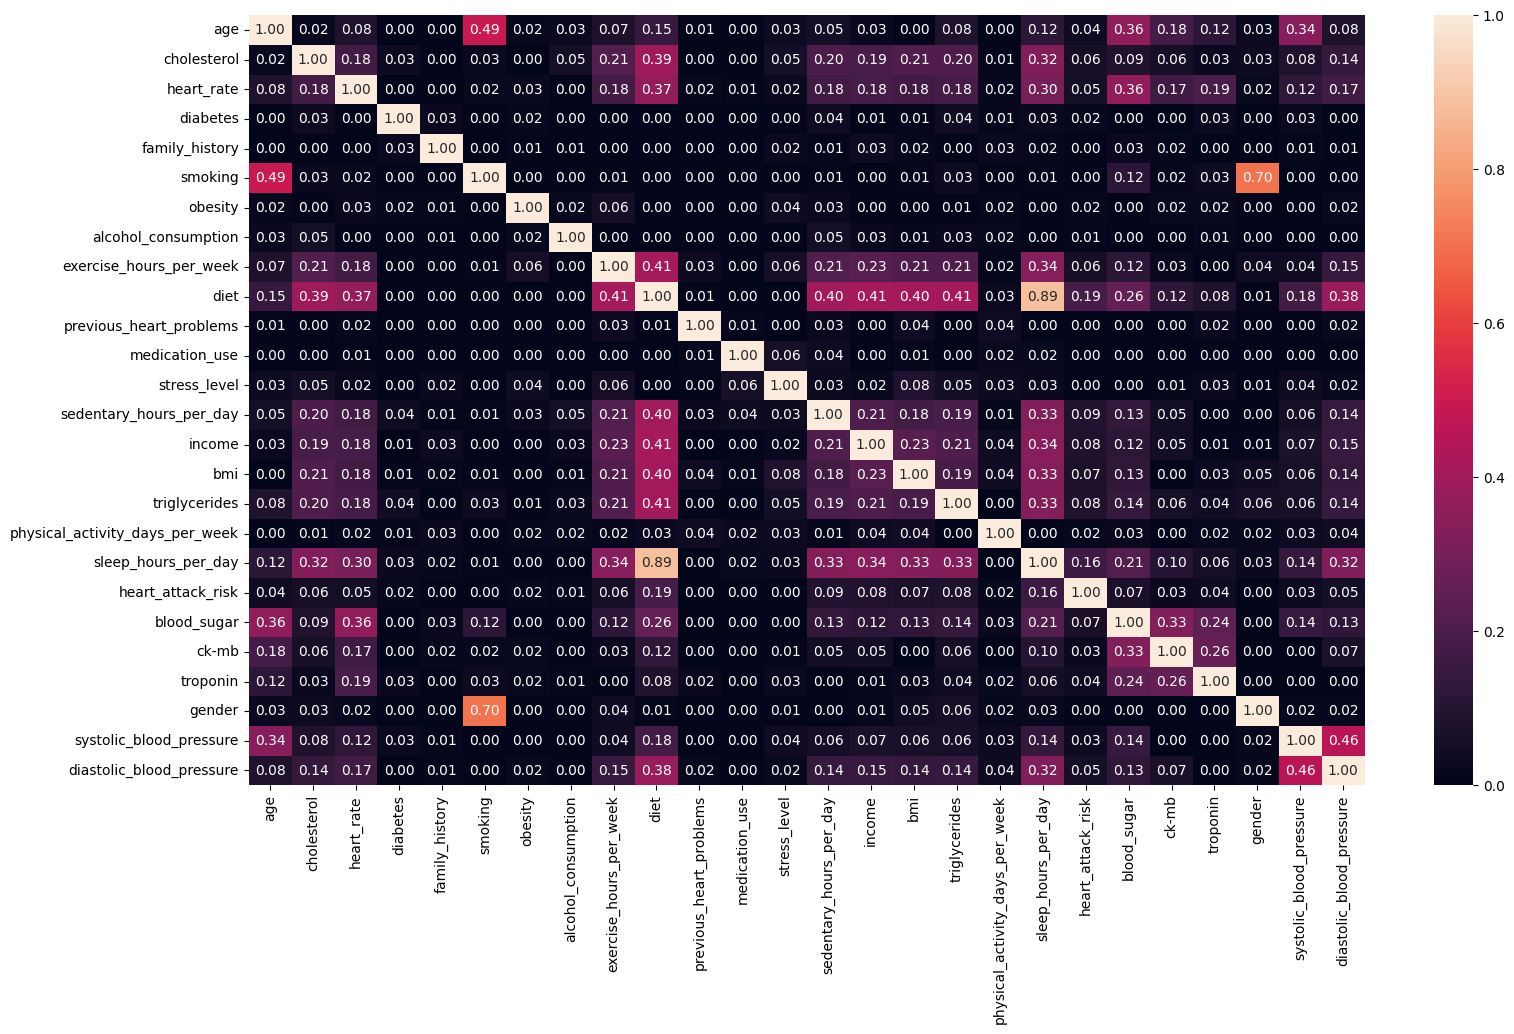

In [237]:
# выделим колонки с количественными и категориальными данными
# num_columns = list(df.select_dtypes(include="number").columns)

# построим матрицу корреляции
correlation_matrix = df_heart_train.phik_matrix(interval_cols=num_cols, verbose=False)

plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f');

Мультиколлинеарности признаков (с коэффициентом зависимости больше 0.9) не наблюдается.

Судя по матрице корреляции, целевой признак (`heart_attack_risk`) слабо зависит от всех признаков. Сильнее всего зависит от признака диеты (`diet`) и количества часов сна в течение дня, но и в этом случае зависимость слабая -- (0,19) и (0,16) соответственно.

### Промежуточные выводы

Матрица корреляции показала слабую зависимость целевого признака от других признаков, представленных в датасете.

## Подготовка данных к обучению моделей

Подготовим тренировочные данные, разобъем на выборки по признакам

In [240]:
X_train_target = df_heart_train.drop("heart_attack_risk", axis=1)
display(X_train_target.head())

y_train_target = df_heart_train["heart_attack_risk"]
display(y_train_target.head())

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,income,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,ck-mb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,
2664,0.36,0.73,0.07,1.00,1.00,1.00,1.00,1.00,0.54,1,1.00,0.00,8.00,0.23,0.11,0.46,0.98,3.00,0.33,0.23,0.05,0.04,Male,0.21,0.71
9287,0.20,0.33,0.05,1.00,1.00,0.00,0.00,1.00,0.07,2,1.00,0.00,9.00,0.29,0.16,0.12,0.52,3.00,0.83,0.15,0.02,0.00,Female,0.41,0.57
5379,0.61,0.86,0.06,1.00,0.00,1.00,1.00,1.00,0.94,2,1.00,1.00,6.00,0.55,0.60,0.37,0.01,2.00,1.00,0.23,0.05,0.04,Female,0.24,0.22
8222,0.73,0.01,0.05,0.00,0.00,1.00,0.00,1.00,0.70,0,0.00,1.00,3.00,0.33,0.08,0.05,0.13,0.00,0.33,0.23,0.05,0.04,Female,0.35,0.27
4047,0.78,0.76,0.02,0.00,0.00,1.00,0.00,1.00,0.41,1,0.00,0.00,8.00,0.52,0.34,0.83,0.07,5.00,1.00,0.23,0.05,0.04,Male,0.62,0.44


id
2664   0.00
9287   0.00
5379   0.00
8222   1.00
4047   1.00
Name: heart_attack_risk, dtype: float64

In [241]:
X_train_target.shape, y_train_target.shape

((8683, 25), (8683,))

Данные готовы к обучению моделей

## Обучение моделей

Подготовим функцию для создания пайплайна и обучения моделей

In [242]:
RANDOM_STATE = 1

In [245]:
def create_pipe_get_random_search(ord_columns, num_columns):
# def create_pipe_get_random_search(ohe_columns, ord_columns, num_columns):
    # Подготовим пайплайны

#     # создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
#     # SimpleImputer + OHE
#     ohe_pipe = Pipeline(
#         [
#             (
#                 "simpleImputer_ohe",
#                 missing_values_pipe,
#             ),
# #             (
# #                 "simpleImputer_space_ohe",
# #                 missing_space_values_pipe,
# #             ),
#             (
#                 "ohe",
#                 OneHotEncoder(
#                     drop="first", 
#                     handle_unknown="ignore", 
#                     sparse_output=False
#                 ),
#             ),
#         ]
#     )

    # cоздаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
    # SimpleImputer + OE
    ord_pipe = Pipeline(
        [
            (
                "simpleImputer_before_ord",
                missing_values_pipe,
            ),
            (
                "ord",
                OrdinalEncoder(
                    categories=[
                        ["Male", "Female"],
                    ],
                    handle_unknown="use_encoded_value",
                    unknown_value=np.nan,
                ),
            ),
            (
                "simpleImputer_after_ord",
                missing_values_pipe,
            ),
        ]
    )

    # пайплайн для подготовки данных
    data_preprocessor = ColumnTransformer(
        [
            # ("ohe", ohe_pipe, ohe_columns),
            ("ord", ord_pipe, ord_columns),
            # ("num", MinMaxScaler(), num_columns),
        ],
        remainder="passthrough",
    )

    # итоговый пайплайн: подготовка данных и модель
    pipe_final = Pipeline(
        [
            ("preprocessor", data_preprocessor),
            ("models", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]
    )

    # Подготовим словари для моделей данных
    param_grid = [
        # словарь для модели DecisionTreeClassifier()
        {
            "models": [DecisionTreeClassifier(random_state=RANDOM_STATE)],
            "models__max_depth": range(2, 20),
            "models__max_features": range(2, 20),
            # "preprocessor__num": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
        },
        # словарь для модели LogisticRegression()
        {
            "models": [
                LogisticRegression(
                    random_state=RANDOM_STATE,
                    solver="liblinear"
                )
            ],
            "models__C": range(1, 5),
            # "preprocessor__num": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
        },
        # словарь для модели SVC()
        {
            "models": [
                SVC(random_state=RANDOM_STATE, kernel="linear", probability=True)
            ],
            "models__C": range(2, 5),
            # "preprocessor__num": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
        },
    ]

    randomized_search = RandomizedSearchCV(
        pipe_final,
        param_grid,
        n_iter=40,
        cv=5,
        scoring="roc_auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    return randomized_search

Разобьем признаки на категориальные и количественные.

In [246]:
# cat_columns = list(X_train_quit.select_dtypes(exclude="number").columns)
print("cat_columns:", cat_cols)

# num_columns = list(X_train_quit.select_dtypes(include="number").columns)
print("num_columns:", num_cols)

# ohe_columns = [
#     "dept",
#     "last_year_promo",
#     "last_year_violations",
# ]
# print("ohe_columns:", ohe_columns)

ord_columns = [
    "gender",
]
print("ord_columns:", ord_columns)

cat_columns: ['diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'diet', 'previous_heart_problems', 'medication_use', 'stress_level', 'physical_activity_days_per_week', 'sleep_hours_per_day', 'gender']
num_columns: ['age', 'cholesterol', 'heart_rate', 'exercise_hours_per_week', 'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides', 'blood_sugar', 'ck-mb', 'troponin', 'systolic_blood_pressure', 'diastolic_blood_pressure']
ord_columns: ['gender']


In [250]:
randomized_search = create_pipe_get_random_search(ord_columns, num_cols)
randomized_search.fit(X_train_target, y_train_target)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print('Метрика лучшей модели на кросс-валидации:', randomized_search.best_score_)

# проверим работу модели на тестовой выборке
# y_train_pred = randomized_search.predict_proba(X_train_target)[:,1]
# print(f'Метрика ROC_AUC_SCORE на тренировочной выборке: {roc_auc_score(y_train_target, y_train_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent'))])),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['Male',
                                                                                               'Female']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=n

ROC_AUC_SCORE на кросс-валидации составила 0.55.

Получим топ-10 моделей для анализа

In [249]:
search_results_df = pd.DataFrame(randomized_search.cv_results_)

# Топ-10 лучших результатов
top_10_results = search_results_df.sort_values(by='rank_test_score').head(10)

# Вывод основных метрик
print("Топ-10 лучших комбинаций параметров:")
top_10_results

Топ-10 лучших комбинаций параметров:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_models__max_features,param_models__max_depth,param_models,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
14,0.04,0.00,0.01,0.00,10,13,DecisionTreeClassifier(random_state=1),"{'models__max_features': 10, 'models__max_depth': 13, 'models': DecisionTreeClassifier(random_state=1)}",0.54,0.55,0.56,0.56,0.54,0.55,0.01,1
31,0.07,0.01,0.01,0.00,13,16,DecisionTreeClassifier(random_state=1),"{'models__max_features': 13, 'models__max_depth': 16, 'models': DecisionTreeClassifier(random_state=1)}",0.55,0.52,0.55,0.57,0.56,0.55,0.01,2
28,0.06,0.01,0.01,0.00,11,18,DecisionTreeClassifier(random_state=1),"{'models__max_features': 11, 'models__max_depth': 18, 'models': DecisionTreeClassifier(random_state=1)}",0.55,0.54,0.54,0.56,0.55,0.55,0.01,3
39,0.03,0.01,0.00,0.00,6,12,DecisionTreeClassifier(random_state=1),"{'models__max_features': 6, 'models__max_depth': 12, 'models': DecisionTreeClassifier(random_state=1)}",0.54,0.54,0.55,0.57,0.54,0.55,0.01,4
37,0.03,0.00,0.01,0.00,3,13,DecisionTreeClassifier(random_state=1),"{'models__max_features': 3, 'models__max_depth': 13, 'models': DecisionTreeClassifier(random_state=1)}",0.56,0.54,0.56,0.54,0.54,0.55,0.01,5
9,0.05,0.01,0.01,0.00,11,12,DecisionTreeClassifier(random_state=1),"{'models__max_features': 11, 'models__max_depth': 12, 'models': DecisionTreeClassifier(random_state=1)}",0.56,0.53,0.57,0.54,0.53,0.55,0.01,6
15,0.05,0.01,0.01,0.00,16,10,DecisionTreeClassifier(random_state=1),"{'models__max_features': 16, 'models__max_depth': 10, 'models': DecisionTreeClassifier(random_state=1)}",0.58,0.52,0.55,0.52,0.55,0.54,0.02,7
34,0.08,0.01,0.01,0.00,14,19,DecisionTreeClassifier(random_state=1),"{'models__max_features': 14, 'models__max_depth': 19, 'models': DecisionTreeClassifier(random_state=1)}",0.57,0.54,0.54,0.54,0.52,0.54,0.01,8
32,0.09,0.01,0.01,0.00,17,15,DecisionTreeClassifier(random_state=1),"{'models__max_features': 17, 'models__max_depth': 15, 'models': DecisionTreeClassifier(random_state=1)}",0.56,0.52,0.53,0.56,0.53,0.54,0.02,9
2,0.02,0.00,0.01,0.00,2,12,DecisionTreeClassifier(random_state=1),"{'models__max_features': 2, 'models__max_depth': 12, 'models': DecisionTreeClassifier(random_state=1)}",0.54,0.54,0.55,0.54,0.53,0.54,0.01,10


Лучшая модель показала стабильные результаты на кросс-валидации (std_test_score = 0.01).

### Промежуточные выводы

- Разбили признаки на категориальные и количественные.
- Использовали ROC-AUC метрику для оценки моделей
- Составили пайплайн, заполнили пропуски в данных и нашли лучшую модель и ее гиперпараметры для задачи регрессии

Лучшей признана модель регрессионного дерева решений со следующими параметрами
DecisionTreeClassifier(max_depth=13, max_features=10, random_state=1)

ROC-AUC показала значение 0.55 на кросс-валидации.

## Анализ важности признаков

In [251]:
preprocessor = randomized_search.best_estimator_.named_steps['preprocessor']
model = randomized_search.best_estimator_.named_steps['models']

In [252]:
X_train_target_piped = preprocessor.fit_transform(X_train_target.copy())
feature_names = preprocessor.get_feature_names_out()

# Получение важности признаков
model.fit(X_train_target_piped, y_train_target)
feature_importances = model.feature_importances_

# Вывод результатов
feature_importances_df = pd.DataFrame(data=zip(feature_names, feature_importances), columns=["feature", "importance"])
feature_importances_df.sort_values(by="importance", ascending=False)

,feature,importance
9,remainder__exercise_hours_per_week,0.09
16,remainder__bmi,0.09
12,remainder__medication_use,0.08
2,remainder__cholesterol,0.07
17,remainder__triglycerides,0.07
24,remainder__diastolic_blood_pressure,0.07
15,remainder__income,0.06
3,remainder__heart_rate,0.06
14,remainder__sedentary_hours_per_day,0.06
1,remainder__age,0.06


Построим SHAP диаграммы для оценки влияния признаков на целевой

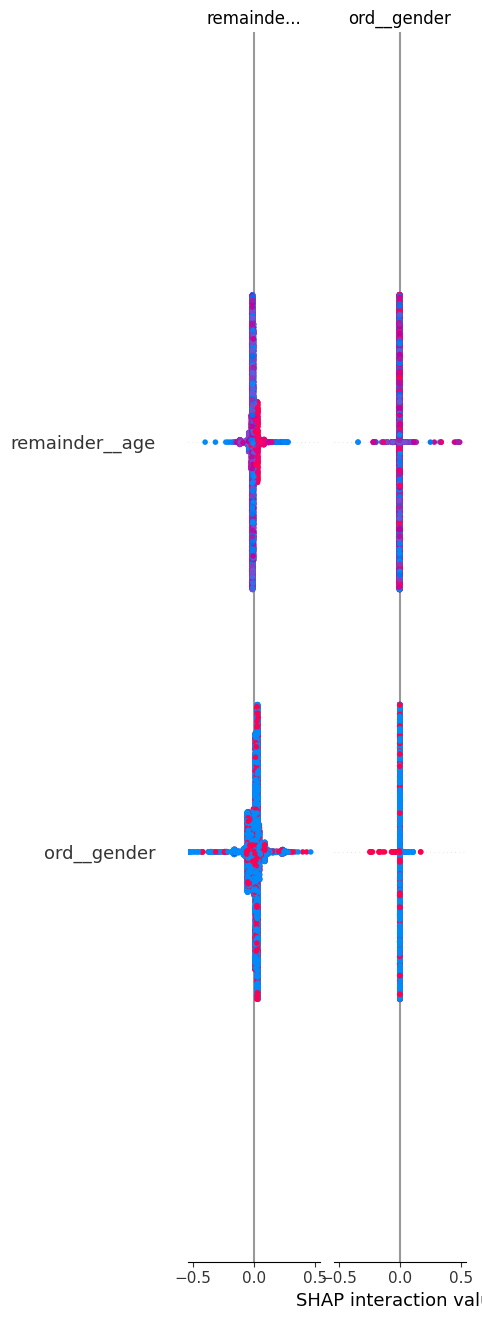

In [260]:
original_features = list(X_train_target.columns)

X_test_piped = preprocessor.transform(X_train_target.copy())
explainer = shap.Explainer(model, X_test_piped)
feature_names = preprocessor.get_feature_names_out()
shap_values = explainer(X_test_piped, check_additivity=False)
 
shap.summary_plot(shap_values, X_test_piped, feature_names=feature_names, max_display=15, plot_size=(15, 5))

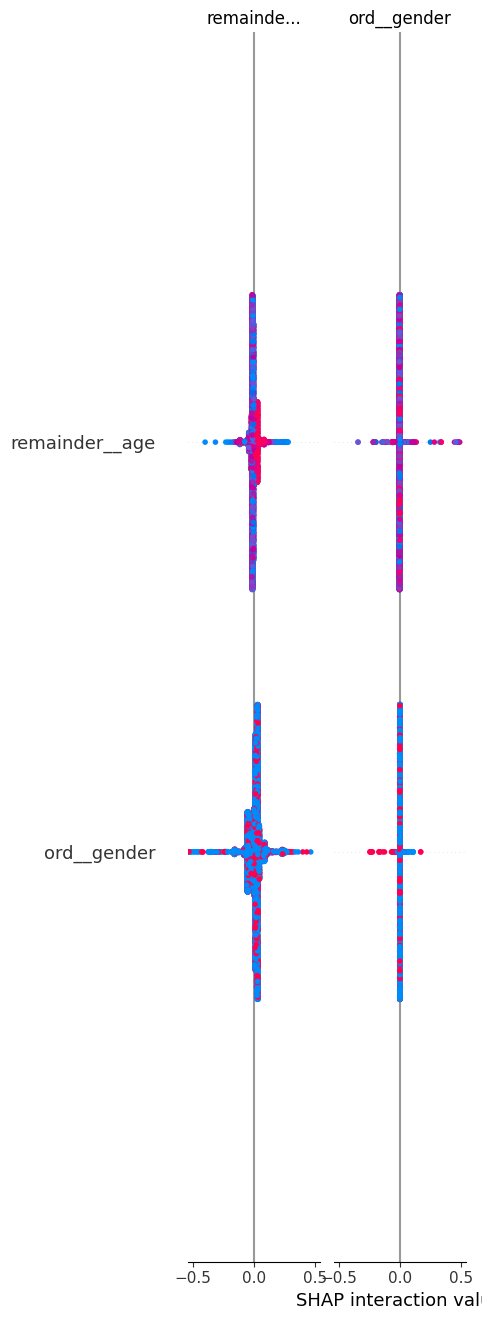

In [258]:
shap.summary_plot(shap_values, X_test_piped, plot_type="bar", feature_names=feature_names, max_display=15, plot_size=(15, 5))

### Промежуточные выводы

На основании анализа важности признаков для модели и SHAP диаграмм видно, что на увольнение сотрудников из компании влияют следующие признаки:
- property
- property

Эти данные подтверждают выводы, сделанные на шаге Исследовательский анализ данных. Несмотря на то, что качество модели соответствует заявленным требованиям, ее качество можно попробовать улучшить, если удалить из датасета колонки, важность которых составляет 0.

## Общий вывод